<a href="https://colab.research.google.com/github/aishaahammed/KPMG1B-Driving_Donations/blob/main/donations_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import numpy as np

# Load the datasets
donations_df = pd.read_csv('DonationsC5LA.csv')
sociodemographics_df = pd.read_csv('ACSSociodemographics.csv')

# Rename 'Billing Zip/Postal Code' to 'ZCTA' in donations_df
donations_df.rename(columns={'Billing Zip/Postal Code': 'ZCTA'}, inplace=True)

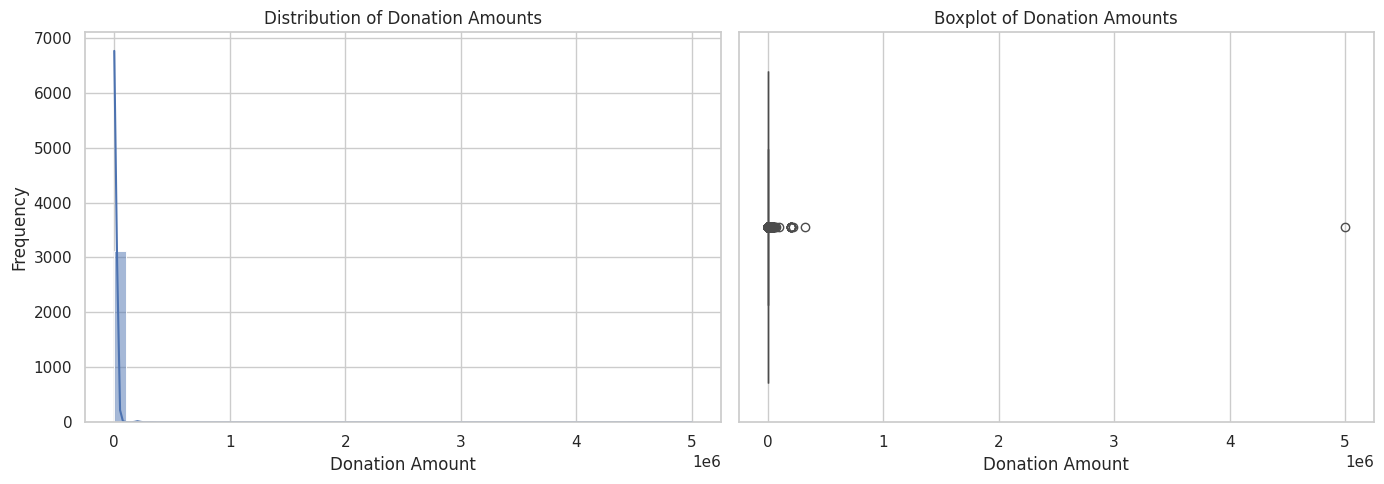

<ipython-input-7-88a8c4eb6fe2>:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donations_by_period = donations_df.groupby('Fiscal Period')['Amount'].sum().reset_index()


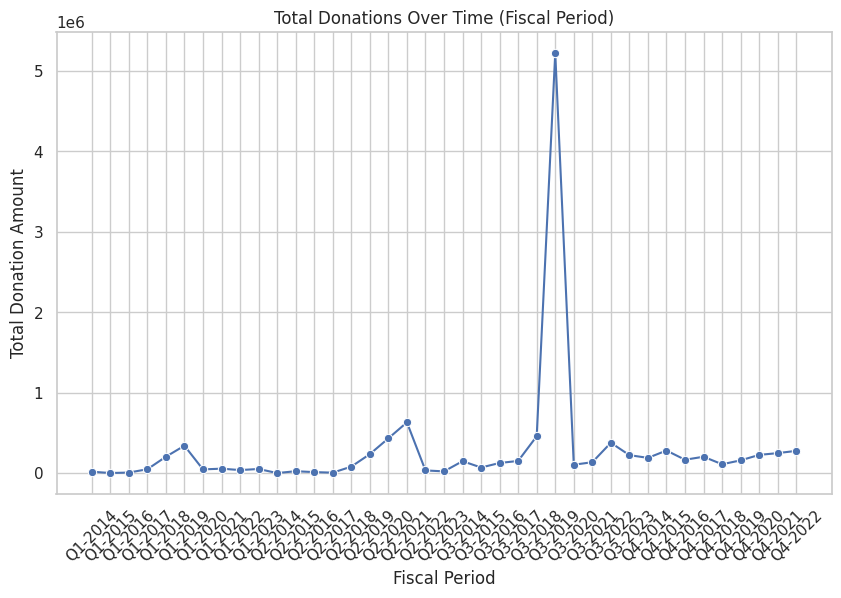

<ipython-input-7-88a8c4eb6fe2>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=donations_by_campaign, x='Amount', y='Maked Primary Campaign', palette='viridis')


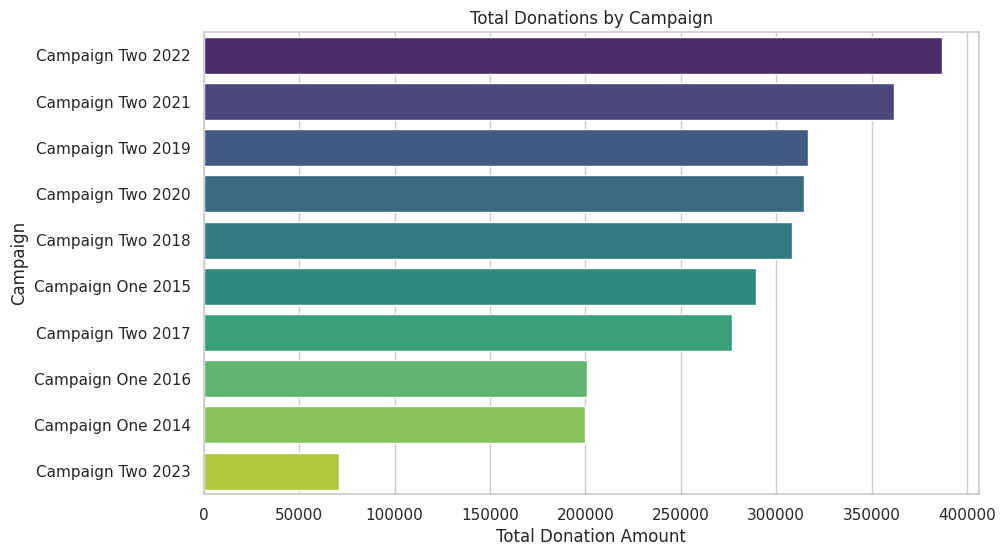

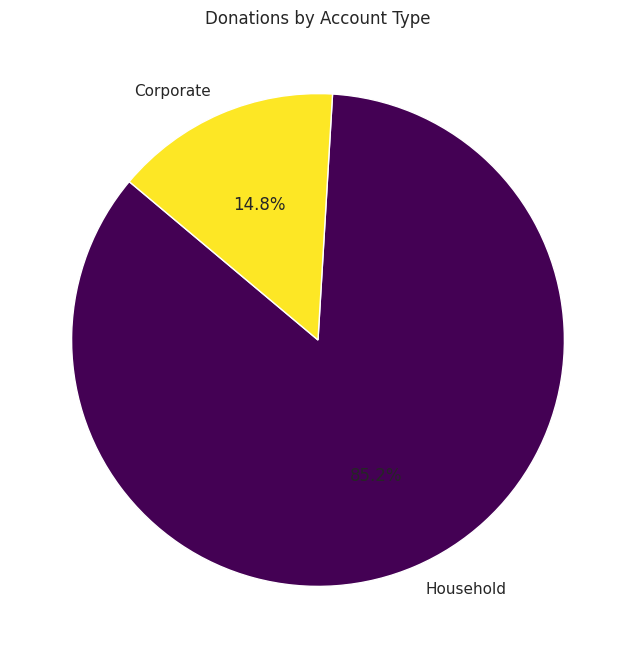

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set general aesthetics for plots
sns.set(style="whitegrid")

# 1. Distribution of Donation Amounts (Histogram & Boxplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Histogram
sns.histplot(donations_df['Amount'], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Donation Amounts")
axes[0].set_xlabel("Donation Amount")
axes[0].set_ylabel("Frequency")

# Boxplot for identifying outliers
sns.boxplot(x=donations_df['Amount'], ax=axes[1])
axes[1].set_title("Boxplot of Donation Amounts")
axes[1].set_xlabel("Donation Amount")

plt.tight_layout()
plt.show()

# 2. Donations Over Time (Line Plot by Fiscal Period)
# Convert Fiscal Period to categorical, ordered by appearance
donations_df['Fiscal Period'] = pd.Categorical(donations_df['Fiscal Period'],
                                               ordered=True,
                                               categories=sorted(donations_df['Fiscal Period'].unique()))

# Summing donations by Fiscal Period
donations_by_period = donations_df.groupby('Fiscal Period')['Amount'].sum().reset_index()

# Line Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=donations_by_period, x='Fiscal Period', y='Amount', marker='o')
plt.title("Total Donations Over Time (Fiscal Period)")
plt.xlabel("Fiscal Period")
plt.ylabel("Total Donation Amount")
plt.xticks(rotation=45)
plt.show()

# 3. Donations by Campaign (Bar Chart)
donations_by_campaign = donations_df.groupby('Maked Primary Campaign')['Amount'].sum().reset_index()
donations_by_campaign = donations_by_campaign.sort_values(by='Amount', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=donations_by_campaign, x='Amount', y='Maked Primary Campaign', palette='viridis')
plt.title("Total Donations by Campaign")
plt.xlabel("Total Donation Amount")
plt.ylabel("Campaign")
plt.show()

# 4. Donations by Account Type (Pie Chart)
donations_by_account_type = donations_df['Account Type'].value_counts()

plt.figure(figsize=(8, 8))
donations_by_account_type.plot(kind='pie', autopct='%1.1f%%', startangle=140, cmap="viridis")
plt.title("Donations by Account Type")
plt.ylabel("")  # Hide the y-label
plt.show()




In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean up any whitespace in the column names
donations_df.columns = donations_df.columns.str.strip()

# Group by zip code, sum donation amounts, and select the top 10
donations_by_zip = donations_df.groupby('ZCTA')['Amount'].sum().reset_index()
donations_by_zip = donations_by_zip.sort_values(by='Amount', ascending=False).head(10)

donations_by_zip


,ZCTA,Amount
154,90069,7363150.69
125,90025,519653.83
23,10016,285424.16
145,90049,224541.74
98,82428,202600.00
180,90272,199819.10
152,90067,150033.53
101,83333,123165.00
235,91311,107980.67
149,90064,100682.00


<ipython-input-15-8500eacbc896>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=donations_by_zip, x='Amount', y='ZCTA', palette='coolwarm')


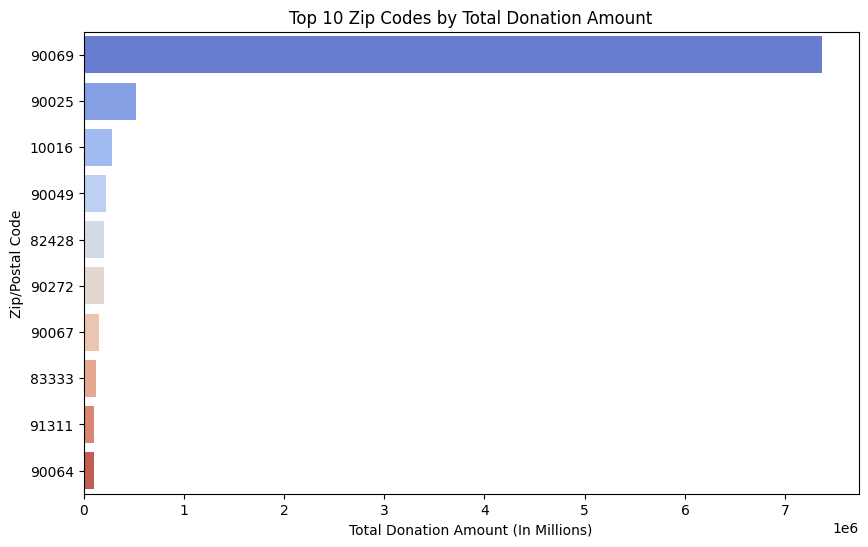

In [ ]:
 # Plot the top 10 zip codes by total donation amount
plt.figure(figsize=(10, 6))
sns.barplot(data=donations_by_zip, x='Amount', y='ZCTA', palette='coolwarm')
plt.title("Top 10 Zip Codes by Total Donation Amount")
plt.xlabel("Total Donation Amount (In Millions)")
plt.ylabel("Zip/Postal Code")
plt.show()

In [ ]:

plt.figure(figsize=(10, 6))
sns.barplot(data=donations_by_zip, x='Amount', y='Billing Zip/Postal Code', palette='coolwarm')
plt.title("Top 10 Zip Codes by Total Donation Amount")
plt.xlabel("Total Donation Amount")
plt.ylabel("Zip/Postal Code")
plt.show()

ValueError: Could not interpret value `Billing Zip/Postal Code` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [ ]:
print(donations_df['Amount'].max())
print(donations_df['Amount'].min())

5000028.69
-200.0


In [ ]:
import numpy as np

# Calculate Q1 and Q3
Q1 = np.percentile(donations_df['Amount'], 25)
Q3 = np.percentile(donations_df['Amount'], 75)
IQR = Q3 - Q1

# Define outliers as values outside the range [Q1 - 1.5*IQR, Q3 + 1.5*IQR] and with account type "Household"
# Define the outlier condition for Amount and Account Type "Household"
outlier_condition = ((donations_df['Amount'] < Q1 - 1.5 * IQR) | (donations_df['Amount'] > Q3 + 1.5 * IQR)) & (donations_df['Account Type'] == 'Household')

donations_df = donations_df[~outlier_condition]


In [ ]:
nan_zcta_count = donations_df['ZCTA'].isna().sum()
print("Number of entries where ZCTA is NaN:", nan_zcta_count)

Number of entries where ZCTA is NaN: 488


In [ ]:
donations_df['ZCTA'] = pd.to_numeric(donations_df['ZCTA'], errors='coerce')

# Drop all entries where ZCTA is NaN
donations_df.dropna(subset=['ZCTA'], inplace=True)

# Convert ZCTA to integer
donations_df['ZCTA'] = donations_df['ZCTA'].astype(int)
donations_df


,Masked Account ID,Maked Primary Campaign,Stage,Account Type,ZCTA,Fiscal Period,Close Date,Amount
19,4,NaN,Closed Won,Household,90049,Q1-2016,3/7/2016,200.0
20,4,NaN,Closed Won,Household,90049,Q2-2017,4/27/2017,100.0
22,4,NaN,Closed Won,Household,90049,Q2-2022,4/14/2022,80.0
23,4,NaN,Closed Won,Household,90049,Q1-2023,1/18/2023,500.0
25,4,NaN,Closed Won,Household,90049,Q4-2018,12/20/2018,500.0
...,...,...,...,...,...,...,...,...
3115,1228,Campaign Two 2023,Closed Won,Household,29406,Q3-2023,8/18/2023,100.0
3116,1232,Campaign Two 2023,Closed Won,Household,90035,Q3-2023,8/8/2023,50.0
3119,1288,Campaign Two 2023,Closed Won,Household,91105,Q3-2023,7/25/2023,1250.0
3120,1289,Campaign Two 2023,Closed Won,Household,90720,Q3-2023,7/29/2023,1250.0


In [ ]:
# Merge the DataFrames on 'ZCTA' using a left join
sociodemographics_unique = sociodemographics_df.drop_duplicates(subset='ZCTA')

merged_df = pd.merge(donations_df, sociodemographics_unique, on='ZCTA')



In [ ]:
merged_df = pd.get_dummies(merged_df, columns=['Account Type'], prefix='Account_Type')
merged_df.head()

,Masked Account ID,Maked Primary Campaign,Stage,ZCTA,Fiscal Period,Close Date,Amount,Year,Pop,Households,...,Health Ins Pop,Health Ins,No Health Ins,Labor Population,Armed Forces,Employed,Unemployed,Not in Labor Force,Account_Type_Corporate,Account_Type_Household
0,4,NaN,Closed Won,90049,Q1-2016,3/7/2016,200.0,2021,35853,16116,...,35853,35209,644,30155,0,19931,880,9344,False,True
1,4,NaN,Closed Won,90049,Q2-2017,4/27/2017,100.0,2021,35853,16116,...,35853,35209,644,30155,0,19931,880,9344,False,True
2,4,NaN,Closed Won,90049,Q2-2022,4/14/2022,80.0,2021,35853,16116,...,35853,35209,644,30155,0,19931,880,9344,False,True
3,4,NaN,Closed Won,90049,Q1-2023,1/18/2023,500.0,2021,35853,16116,...,35853,35209,644,30155,0,19931,880,9344,False,True
4,4,NaN,Closed Won,90049,Q4-2018,12/20/2018,500.0,2021,35853,16116,...,35853,35209,644,30155,0,19931,880,9344,False,True


In [ ]:
nan_count = filtered_df.isna().sum().sum()
print(f"Number of NaNs: {nan_count}")

nan_entries = filtered_df[filtered_df.isna().any(axis=1)]
print("Entries with NaN values:")
print(nan_entries)

NameError: name 'filtered_df' is not defined

In [ ]:

# Select columns that contain '%' in their names or are 'Amount'
percentage_columns = [col for col in merged_df.columns if '%' in col]
for col in percentage_columns:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')
percentage_columns.append('Amount')  # Include the 'Amount' column explicitly

percentage_columns.append('Account_Type_Corporate')
percentage_columns.append('Account_Type_Household')
percentage_columns.append('Under 35 %')

# Subset the merged_df to include only the selected columns and ensure all rows are preserved
filtered_df = merged_df[percentage_columns]
filtered_df.columns.values


array(['Minority %', 'Poor %', 'Poor Family %', 'Car or Van %',
       'Public Transport %', 'Health Ins %', 'No Health Ins %',
       'Unemployed %', 'Employed %', 'Armed Forces %',
       'Not in Labor Force %', 'Under 10 %', 'Under 35 %', 'Over 65 %',
       'Over 85 %', 'High school %', 'College %', '0-50k %', '50-100k %',
       '100-150k %', '150-200k %', '200k+ %', 'Amount',
       'Account_Type_Corporate', 'Account_Type_Household', 'Under 35 %'],
      dtype=object)

In [ ]:
# Combined filtered DataFrame and mean calculation for both
print(f"Mean Amount for Account_Type_Corporate: {merged_df[merged_df['Account_Type_Corporate'] == 1]['Amount'].mean()}")
print(f"Mean Amount for Account_Type_Household: {merged_df[merged_df['Account_Type_Household'] == 1]['Amount'].mean()}")


Mean Amount for Account_Type_Corporate: 4220.67435483871
Mean Amount for Account_Type_Household: 325.5834517258629


In [ ]:
# List of income percentage columns
income_percents = [
    '200k+ %', '0-50k %', '150-200k %', '100-150k %'
    # Add other income percentage columns as needed
]

# Create a function to determine the category where the cumulative sum exceeds 50%
def find_category(row):
    cumulative_sum = 0
    for i, col in enumerate(income_percents):
        cumulative_sum += row[col]  # Add the percentage for this category

        if cumulative_sum >= 0.5:  # Check if cumulative sum has exceeded 50%
            return i + 1  # Return the index or corresponding numerical value of the category
    return 0  # If no category exceeds 50%

# Apply the function to find the category for each row
filtered_df['Income_Category'] = filtered_df.apply(find_category, axis=1)

# Display the DataFrame with the new 'Income_Category' column
print(filtered_df[['Amount', 'Income_Category'] + income_percents].head())
print(np.mean(filtered_df['Income_Category']))


   Amount  Income_Category   200k+ %   0-50k %  150-200k %  100-150k %
0   200.0                2  0.355858  0.179263    0.122239     0.16859
1   100.0                2  0.355858  0.179263    0.122239     0.16859
2    80.0                2  0.355858  0.179263    0.122239     0.16859
3   500.0                2  0.355858  0.179263    0.122239     0.16859
4   500.0                2  0.355858  0.179263    0.122239     0.16859
2.444959932517925


<ipython-input-27-0c6d041158f0>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Income_Category'] = filtered_df.apply(find_category, axis=1)


In [ ]:
filtered_df = filtered_df.loc[:, ~filtered_df.columns.duplicated()]

filtered_df.head()

,Minority %,Poor %,Poor Family %,Car or Van %,Public Transport %,Health Ins %,No Health Ins %,Unemployed %,Employed %,Armed Forces %,...,College %,0-50k %,50-100k %,100-150k %,150-200k %,200k+ %,Amount,Account_Type_Corporate,Account_Type_Household,Income_Category
0,0.184336,0.069372,0.015823,0.620955,0.021321,0.982038,0.017962,0.029183,0.660952,0.0,...,1.740857,0.179263,0.174051,0.16859,0.122239,0.355858,200.0,False,True,2
1,0.184336,0.069372,0.015823,0.620955,0.021321,0.982038,0.017962,0.029183,0.660952,0.0,...,1.740857,0.179263,0.174051,0.16859,0.122239,0.355858,100.0,False,True,2
2,0.184336,0.069372,0.015823,0.620955,0.021321,0.982038,0.017962,0.029183,0.660952,0.0,...,1.740857,0.179263,0.174051,0.16859,0.122239,0.355858,80.0,False,True,2
3,0.184336,0.069372,0.015823,0.620955,0.021321,0.982038,0.017962,0.029183,0.660952,0.0,...,1.740857,0.179263,0.174051,0.16859,0.122239,0.355858,500.0,False,True,2
4,0.184336,0.069372,0.015823,0.620955,0.021321,0.982038,0.017962,0.029183,0.660952,0.0,...,1.740857,0.179263,0.174051,0.16859,0.122239,0.355858,500.0,False,True,2


In [ ]:
print("Entries in filtered_df where 'amount' is NaN:")
print(filtered_df[filtered_df['Amount'].isna()])

Entries in filtered_df where 'amount' is NaN:
Empty DataFrame
Columns: [Minority %, Poor %, Poor Family %, Car or Van %, Public Transport %, Health Ins %, No Health Ins %, Unemployed %, Employed %, Armed Forces %, Not in Labor Force %, Under 10 %, Under 35 %, Over 65 %, Over 85 %, High school %, College %, 0-50k %, 50-100k %, 100-150k %, 150-200k %, 200k+ %, Amount, Account_Type_Corporate, Account_Type_Household, Income_Category]
Index: []

[0 rows x 26 columns]


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Log-transform the 'Amount' column
filtered_df['Log_Amount'] = np.log(filtered_df['Amount']+1)  # Adding 1 to avoid log(0) issues

filtered_df = filtered_df.dropna(subset=['Log_Amount'])
print(filtered_df[filtered_df['Log_Amount'].isna()])

Empty DataFrame
Columns: [Minority %, Poor %, Poor Family %, Car or Van %, Public Transport %, Health Ins %, No Health Ins %, Unemployed %, Employed %, Armed Forces %, Not in Labor Force %, Under 10 %, Under 35 %, Over 65 %, Over 85 %, High school %, College %, 0-50k %, 50-100k %, 100-150k %, 150-200k %, 200k+ %, Amount, Account_Type_Corporate, Account_Type_Household, Income_Category, Log_Amount]
Index: []

[0 rows x 27 columns]


/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
filtered_df['Log_Amount'].max()

11.225256725762893

In [ ]:
# List of income percentage columns
income_percents = [
    '200k+ %', '0-50k %', '150-200k %', '100-150k %'
    # Add other income percentage columns as needed
]

# Calculate the cumulative percentage across all columns for each row and take the last cumulative value
filtered_df['Cumulative_Income'] = filtered_df[income_percents].cumsum(axis=1).iloc[:, -1]

# Check which category has the cumulative sum that exceeds 50%
def find_category(row):
    cumulative_sum = 0
    for i, col in enumerate(income_percents):
        cumulative_sum += row[col]  # Add percentage for this category
        if cumulative_sum >= 0.5:  # Check if the cumulative sum exceeds 50%
            return i + 1  # Return the category index (1-based)
    return 0  # Return 0 if no category exceeds 50%

# Apply the function to find the category for each row
filtered_df['Income_Category'] = filtered_df.apply(find_category, axis=1)

# Fill missing values with 0 (if applicable)
filtered_df = filtered_df.fillna(0)

# Select only the numerical columns (including True/False columns as 0/1)
numerical_columns = filtered_df.select_dtypes(include=['float64', 'int64', 'bool']).columns

# Calculate the correlation of all numerical columns with the target column 'Amount'
correlation_with_amount = filtered_df[numerical_columns].corr()['Log_Amount']

# Sort the correlations by the absolute magnitude (ignoring the sign)
sorted_correlations = correlation_with_amount.abs().sort_values(ascending=False)

# Print the sorted correlations
print(sorted_correlations)


Log_Amount                1.000000
Amount                    0.491992
Account_Type_Corporate    0.474634
Account_Type_Household    0.474634
Poor Family %             0.218186
Over 85 %                 0.199634
Under 10 %                0.189494
Over 65 %                 0.156830
High school %             0.147976
No Health Ins %           0.146339
50-100k %                 0.145186
Car or Van %              0.140173
Unemployed %              0.140038
College %                 0.139530
200k+ %                   0.135882
Minority %                0.134528
Income_Category           0.124000
0-50k %                   0.123234
Under 35 %                0.096088
Cumulative_Income         0.086624
Poor %                    0.074079
Public Transport %        0.062066
150-200k %                0.056584
Health Ins %              0.040207
Employed %                0.037456
Not in Labor Force %      0.018408
Armed Forces %            0.016796
100-150k %                0.005546
Name: Log_Amount, dt

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

# Select features and target variable
X = filtered_df[['Account_Type_Household', 'Poor Family %', 'Over 85 %', 'Under 10 %', 'Over 65 %', 'High school %',]]
y = filtered_df['Amount']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Calculate Mean Squared Error and R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Feature importance
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns.values, 'Importance': importances})
print(feature_importance_df.sort_values(by='Importance', ascending=False))



Mean Squared Error: 13332218.556610737
R-squared: 0.19222298467765309
                  Feature  Importance
4               Over 65 %    0.476315
0  Account_Type_Household    0.303248
5           High school %    0.084185
2               Over 85 %    0.064893
3              Under 10 %    0.036436
1           Poor Family %    0.034923


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFECV
import pandas as pd

# Define X and y by dropping 'Log_Amount' and 'Amount' from filtered_df
X = filtered_df.drop(columns=['Log_Amount', 'Amount'])
y = filtered_df['Amount']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Use Recursive Feature Elimination with Cross-Validation to find the best features
selector = RFECV(estimator=rf_model, scoring='neg_mean_squared_error', cv=5)
selector = selector.fit(X_train, y_train)

# Get the optimal features and their importance
best_features = X.columns[selector.support_]
print("Best features:", best_features)

# Train the Random Forest model with the selected features only
rf_model.fit(X_train[best_features], y_train)

# Make predictions
y_pred = rf_model.predict(X_test[best_features])

# Calculate Mean Squared Error and R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Mean Squared Error with selected features: {mse}")
print(f"R-squared with selected features: {r2}")

# Feature importance for the selected model
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': best_features, 'Importance': importances})
print(feature_importance_df.sort_values(by='Importance', ascending=False))


Best features: Index(['Car or Van %', 'Public Transport %', 'Unemployed %', 'Employed %',
       'Armed Forces %', 'Not in Labor Force %', 'Under 35 %', 'Over 65 %',
       'Over 85 %', '150-200k %', 'Account_Type_Corporate',
       'Account_Type_Household', 'Cumulative_Income'],
      dtype='object')
Mean Squared Error with selected features: 13106151.860601144
R-squared with selected features: 0.2059199909329148
                   Feature  Importance
6               Under 35 %    0.242731
0             Car or Van %    0.183600
10  Account_Type_Corporate    0.124416
11  Account_Type_Household    0.117361
4           Armed Forces %    0.060421
1       Public Transport %    0.051690
3               Employed %    0.049341
7                Over 65 %    0.041580
2             Unemployed %    0.034298
12       Cumulative_Income    0.031709
8                Over 85 %    0.030896
5     Not in Labor Force %    0.017491
9               150-200k %    0.014466


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

# Initialize the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Perform cross-validation with negative MSE as the scoring metric
cv_mse_scores = cross_val_score(rf_model, X, y, cv=5, scoring='neg_mean_squared_error')
print(f"Cross-validated Mean Squared Error: {-cv_mse_scores.mean()}")

# Perform cross-validation with R-squared as the scoring metric
cv_r2_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
print(f"Cross-validated Mean R-squared: {cv_r2_scores.mean()}")


Cross-validated Mean Squared Error: 11050513.574807312


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFECV
import pandas as pd

# Define X and y by dropping 'Log_Amount' and 'Amount' from filtered_df
X = filtered_df.drop(columns=['Log_Amount', 'Amount'])
y = filtered_df['Amount']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Lasso with cross-validation to determine the best alpha
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)

# Use Recursive Feature Elimination with Cross-Validation to find the best features
selector = RFECV(estimator=lasso, scoring='neg_mean_squared_error', cv=5)
selector = selector.fit(X_train, y_train)

# Get the optimal features
best_features = X.columns[selector.support_]
print("Best features:", best_features)

# Train the Lasso model with the selected features only
lasso.fit(X_train[best_features], y_train)

# Make predictions
y_pred = lasso.predict(X_test[best_features])

# Calculate Mean Squared Error and R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Mean Squared Error with selected features: {mse}")
print(f"R-squared with selected features: {r2}")

# Coefficients for the selected features
feature_importance_df = pd.DataFrame({'Feature': best_features, 'Coefficient': lasso.coef_})
print(feature_importance_df.sort_values(by='Coefficient', ascending=False))


Best features: Index(['Minority %', 'Poor %', 'Poor Family %', 'Car or Van %',
       'Public Transport %', 'Health Ins %', 'No Health Ins %', 'Unemployed %',
       'Employed %', 'Armed Forces %', 'Not in Labor Force %', 'Under 10 %',
       'Under 35 %', 'Over 65 %', 'Over 85 %', 'High school %', 'College %',
       '0-50k %', '50-100k %', '100-150k %', '150-200k %', '200k+ %',
       'Account_Type_Corporate', 'Account_Type_Household', 'Income_Category',
       'Cumulative_Income'],
      dtype='object')
Mean Squared Error with selected features: 14886916.826654691
R-squared with selected features: 0.0980263944424733
                   Feature   Coefficient
12              Under 35 %  7.948158e+03
13               Over 65 %  6.708357e+03
22  Account_Type_Corporate  3.536977e+03
21                 200k+ %  1.499881e+03
4       Public Transport %  6.460450e+02
24         Income_Category  1.474059e+02
1                   Poor % -0.000000e+00
2            Poor Family %  0.000000e+00
8   

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import pandas as pd
import numpy as np

# Define X and y by dropping 'Log_Amount' and 'Amount' from filtered_df
X = filtered_df.drop(columns=['Log_Amount', 'Amount'])
y = filtered_df['Amount']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Set up the parameter grid for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Initialize the Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_model, param_distributions=param_dist,
    n_iter=20, cv=5, verbose=1, scoring='r2', random_state=42, n_jobs=-1
)

# Fit RandomizedSearchCV to find the best parameters
random_search.fit(X_train, y_train)

# Use the best estimator to predict
best_rf_model = random_search.best_estimator_
y_pred = best_rf_model.predict(X_test)

# Calculate Mean Squared Error and R-squared
mse


Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
20 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/

14886916.826654691

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X, y)

print("Best parameters found: ", grid_search.best_params_)

# Use the best model from grid search
best_rf_model = grid_search.best_estimator_
cv_r2_scores = cross_val_score(best_rf_model, X, y, cv=5, scoring='r2')
print(f"Cross-validated Mean R-squared with best parameters: {cv_r2_scores.mean()}")


Best parameters found:  {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Cross-validated Mean R-squared with best parameters: 0.2523901526369018


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

# Define the model
gb_model = GradientBoostingRegressor(random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Set up GridSearchCV
grid_search = GridSearchCV(gb_model, param_grid, cv=5, scoring='r2', n_jobs=-1)

# Fit GridSearchCV to find the best parameters
grid_search.fit(X_train, y_train)

# Use the best estimator to predict
best_gb_model = grid_search.best_estimator_
y_pred = best_gb_model.predict(X_test)

# Calculate Mean Squared Error and R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error with Gradient Boosting: {mse}")
print(f"R-squared with Gradient Boosting: {r2}")

NameError: name 'X_train' is not defined